In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the dataset (it's actually CSV format, despite the .xls name)
df = pd.read_csv('../data/raw/telco-dataset.xls')

# Check the shape
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Display first 5 rows
df.head()

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Column names
print("Columns:", df.columns.tolist())
print("\n")

# Data types summary
print("Data types:\n", df.dtypes.value_counts())

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Data types:
 str        18
int64       2
float64     1
Name: count, dtype: int64


In [6]:
# Try converting TotalCharges to numeric - errors will reveal problem rows
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [7]:
# Show the actual problematic rows
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
# Look at the tenure of these problematic rows
problem_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]
problem_rows[['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [9]:
# Convert TotalCharges to numeric (empty strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with 0 (these are new customers with tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify fix
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())
print("Data type now:", df['TotalCharges'].dtype)

Missing values in TotalCharges: 0
Data type now: float64


In [10]:
# Count of each class
print("Churn counts:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


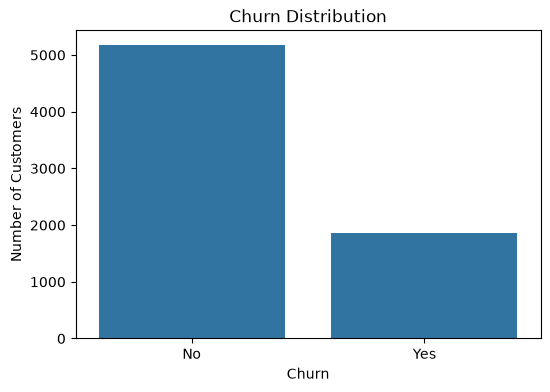

In [11]:
# Visualize the class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [12]:
# Statistical summary of numerical features
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


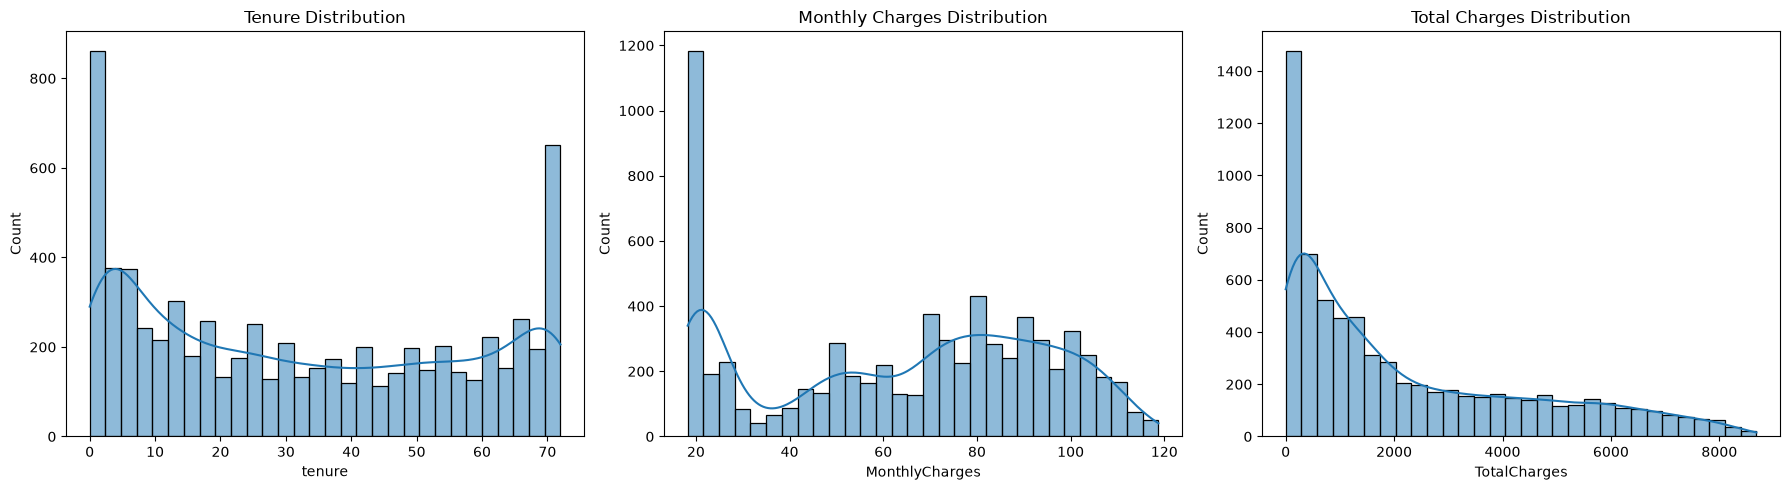

In [13]:
# Plot distributions of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Monthly Charges Distribution')

sns.histplot(df['TotalCharges'], bins=30, ax=axes[2], kde=True)
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

Outlier Detection

IQR (Interquartile Range) Method


In [14]:
# IQR method for outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check each numerical column
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (valid range: {lower:.2f} to {upper:.2f})")

tenure: 0 outliers (valid range: -60.00 to 124.00)
MonthlyCharges: 0 outliers (valid range: -46.02 to 171.38)
TotalCharges: 0 outliers (valid range: -4683.52 to 8868.67)


Z-Score Method

In [15]:
from scipy import stats

# Z-score method for outlier detection
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_count = (z_scores > 3).sum()
    print(f"{col}: {outliers_count} outliers (|Z-score| > 3)")

tenure: 0 outliers (|Z-score| > 3)
MonthlyCharges: 0 outliers (|Z-score| > 3)
TotalCharges: 0 outliers (|Z-score| > 3)


Bivariate Analysis

1️⃣ Churn vs Demographics

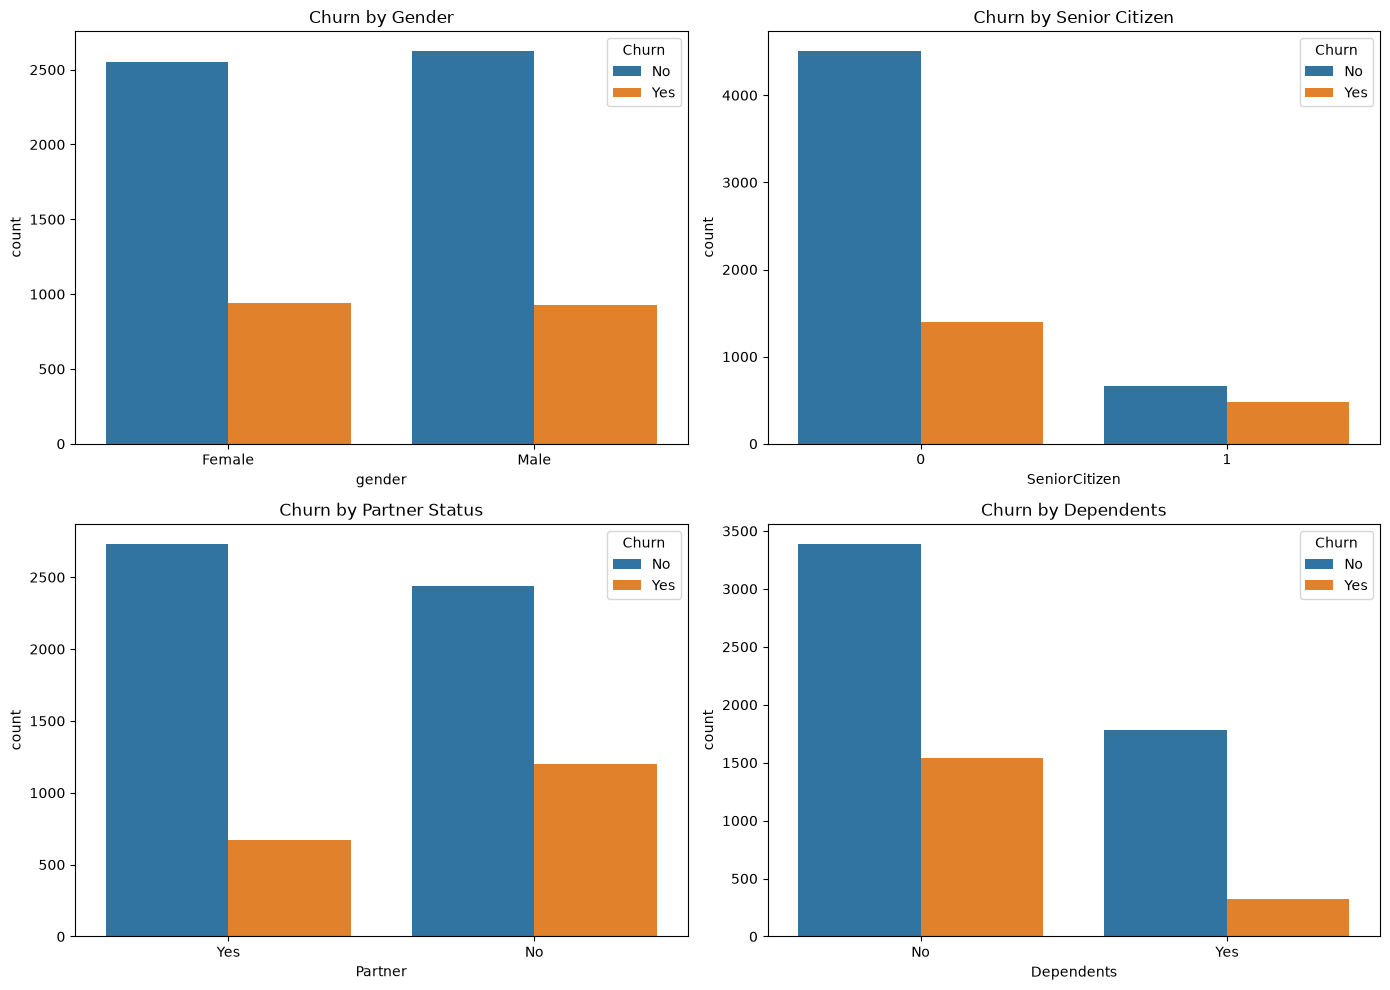

In [16]:
# Demographics vs Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn by Gender')

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Senior Citizen')

sns.countplot(data=df, x='Partner', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Churn by Partner Status')

sns.countplot(data=df, x='Dependents', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Churn by Dependents')

plt.tight_layout()
plt.show()

2️⃣ Churn vs Services

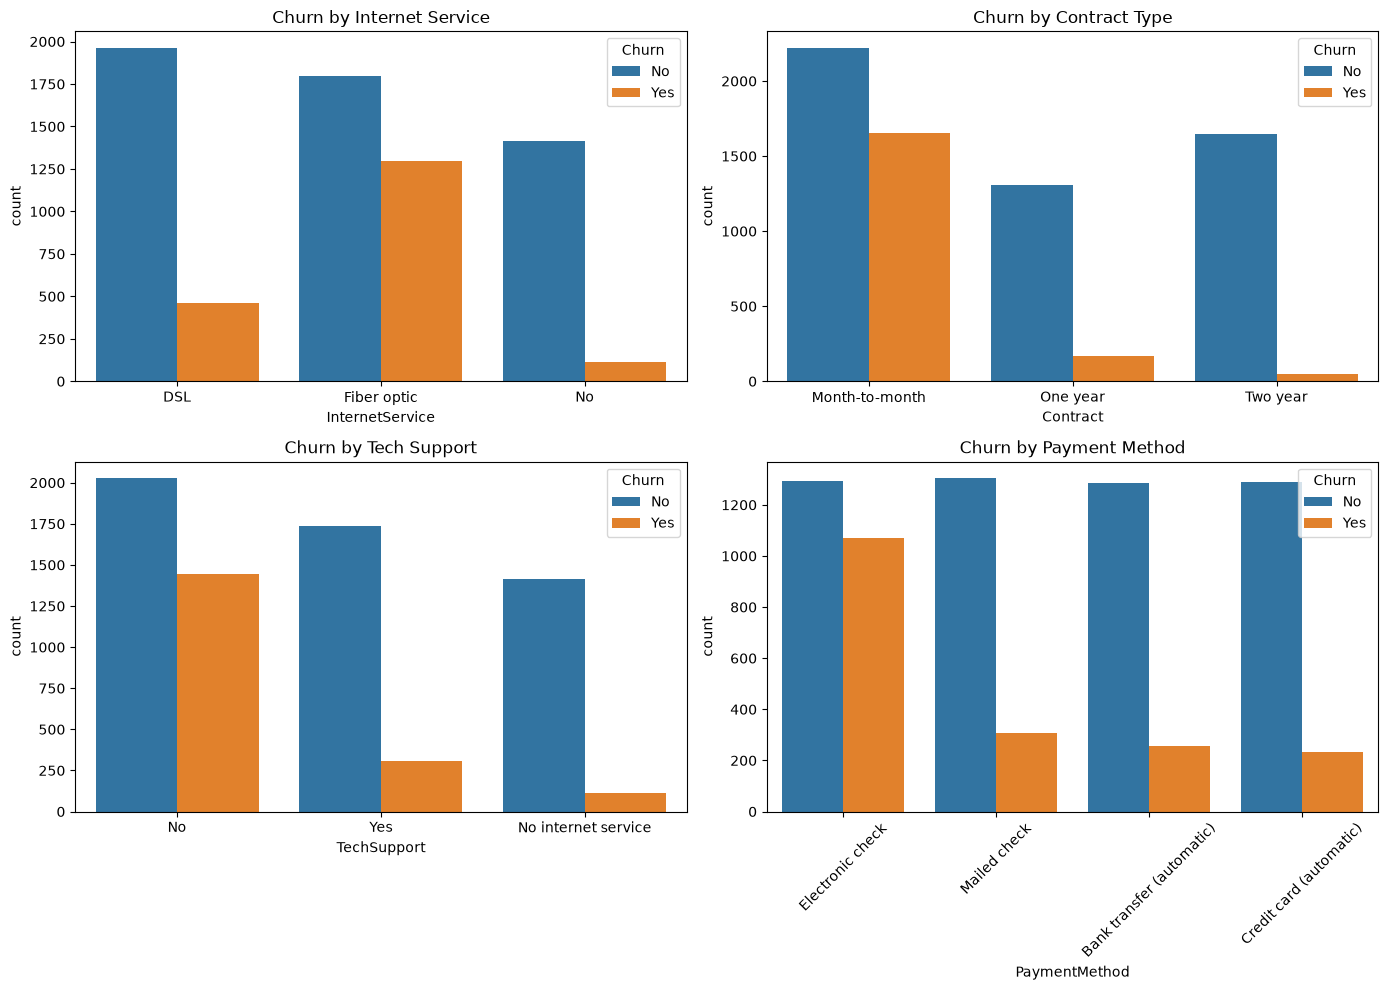

In [17]:
# Services vs Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn by Internet Service')

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Contract Type')

sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Churn by Tech Support')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Churn by Payment Method')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

3️⃣ Churn vs Financial

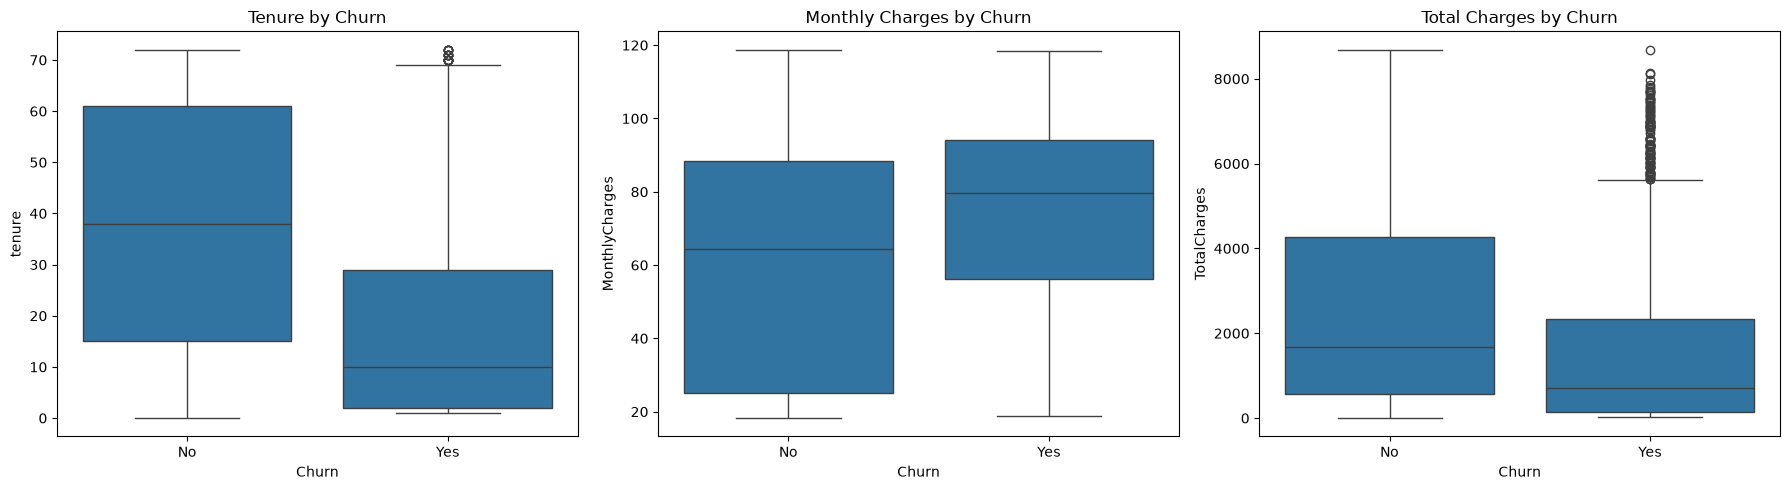

In [18]:
# Financial features vs Churn (boxplots for numeric data)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()
plt.show()

4️⃣ Statistical Significance (Chi-square Test)

In [19]:
from scipy.stats import chi2_contingency

# Chi-square test: Contract vs Churn
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contract vs Churn")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.10f}")
if p_value < 0.05:
    print("=> Statistically significant relationship (p < 0.05)")
else:
    print("=> No significant relationship (p >= 0.05)")

Contract vs Churn
Chi-square statistic: 1184.60
P-value: 0.0000000000
=> Statistically significant relationship (p < 0.05)


Multivariate Analysis

1️⃣ Correlation Matrix

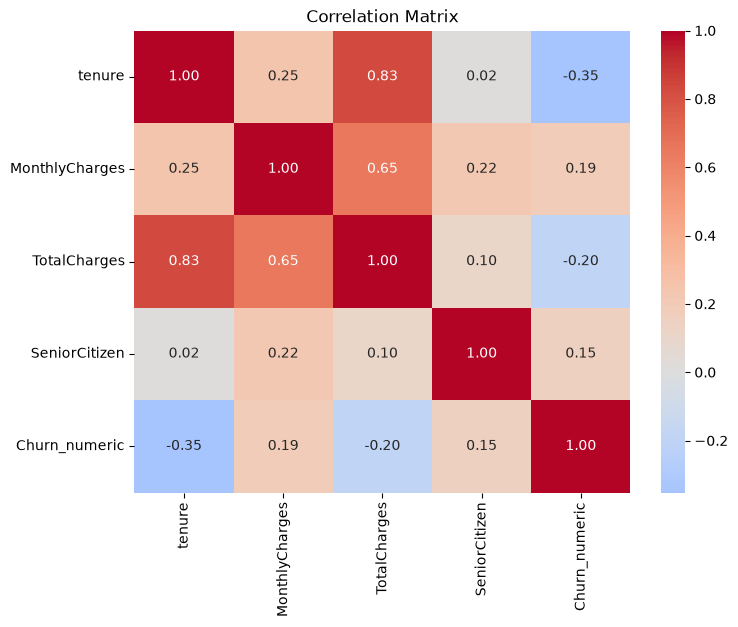

In [20]:
# Create a temporary numeric version of Churn for correlation
df_temp = df.copy()
df_temp['Churn_numeric'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

# Correlation matrix
corr_matrix = df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']].corr()

# Visualize as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix')
plt.show()

2️⃣ Feature Interaction

In [21]:
# Cross-tab: Contract + PaymentMethod combined effect on churn
interaction = df.groupby(['Contract', 'PaymentMethod'])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

print("Churn Rate (%) by Contract + Payment Method combination:")
print(interaction.sort_values(ascending=False))

Churn Rate (%) by Contract + Payment Method combination:
Contract        PaymentMethod            
Month-to-month  Electronic check             53.7
                Bank transfer (automatic)    34.1
                Credit card (automatic)      32.8
                Mailed check                 31.6
One year        Electronic check             18.4
                Credit card (automatic)      10.3
                Bank transfer (automatic)     9.7
Two year        Electronic check              7.7
One year        Mailed check                  6.8
Two year        Bank transfer (automatic)     3.4
                Credit card (automatic)       2.2
                Mailed check                  0.8
Name: Churn, dtype: float64


3️⃣ Simple Customer Segmentation (Behavior Pattern Groups)

In [22]:
# Simple segmentation based on tenure and monthly charges
df_temp['tenure_group'] = pd.cut(df_temp['tenure'], bins=[0,12,24,48,72], 
                                    labels=['0-12mo', '13-24mo', '25-48mo', '49-72mo'])
df_temp['charge_group'] = pd.cut(df_temp['MonthlyCharges'], bins=[0,35,70,120], 
                                    labels=['Low', 'Medium', 'High'])

segment_churn = df_temp.groupby(['tenure_group', 'charge_group'], observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

print("Churn Rate (%) by Tenure + Charge Segment:")
print(segment_churn.sort_values(ascending=False))

Churn Rate (%) by Tenure + Charge Segment:
tenure_group  charge_group
0-12mo        High            68.0
13-24mo       High            45.6
0-12mo        Medium          43.6
25-48mo       High            32.1
0-12mo        Low             23.9
13-24mo       Medium          22.2
49-72mo       High            13.4
25-48mo       Medium          10.5
13-24mo       Low              5.5
49-72mo       Medium           5.3
25-48mo       Low              4.3
49-72mo       Low              1.3
Name: Churn, dtype: float64


Business Insights Generation

1️⃣ High-Risk Customer Profile Identify

In [23]:
# Calculate churn rate for the highest-risk profile combination
high_risk = df[
    (df['Contract'] == 'Month-to-month') & 
    (df['PaymentMethod'] == 'Electronic check') &
    (df['tenure'] <= 12)
]

churn_rate_high_risk = (high_risk['Churn'] == 'Yes').mean() * 100
print(f"High-risk segment size: {len(high_risk)} customers")
print(f"Churn rate in this segment: {churn_rate_high_risk:.1f}%")

# Compare to overall churn rate
overall_churn = (df['Churn'] == 'Yes').mean() * 100
print(f"\nOverall churn rate: {overall_churn:.1f}%")
print(f"Risk multiplier: {churn_rate_high_risk/overall_churn:.1f}x higher than average")

High-risk segment size: 954 customers
Churn rate in this segment: 63.1%

Overall churn rate: 26.5%
Risk multiplier: 2.4x higher than average


2️⃣ Revenue Impact Calculate

In [24]:
# Estimate revenue at risk from churned customers
churned_customers = df[df['Churn'] == 'Yes']
monthly_revenue_lost = churned_customers['MonthlyCharges'].sum()
annual_revenue_lost = monthly_revenue_lost * 12

print(f"Number of churned customers: {len(churned_customers)}")
print(f"Monthly revenue lost: ${monthly_revenue_lost:,.2f}")
print(f"Projected annual revenue loss: ${annual_revenue_lost:,.2f}")

# Average revenue per churned customer
avg_revenue_per_churned = churned_customers['MonthlyCharges'].mean()
print(f"Average monthly charge of churned customers: ${avg_revenue_per_churned:.2f}")

Number of churned customers: 1869
Monthly revenue lost: $139,130.85
Projected annual revenue loss: $1,669,570.20
Average monthly charge of churned customers: $74.44


3️⃣ Retention Opportunity (Low-Risk Factors) Identify

In [25]:
# Compare churn rate with vs without key retention services
retention_services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']

print("Impact of Add-on Services on Churn Rate:")
for service in retention_services:
    churn_with = (df[df[service] == 'Yes']['Churn'] == 'Yes').mean() * 100
    churn_without = (df[df[service] == 'No']['Churn'] == 'Yes').mean() * 100
    print(f"{service}: WITH service = {churn_with:.1f}% churn | WITHOUT service = {churn_without:.1f}% churn")

Impact of Add-on Services on Churn Rate:
OnlineSecurity: WITH service = 14.6% churn | WITHOUT service = 41.8% churn
TechSupport: WITH service = 15.2% churn | WITHOUT service = 41.6% churn
OnlineBackup: WITH service = 21.5% churn | WITHOUT service = 39.9% churn
DeviceProtection: WITH service = 22.5% churn | WITHOUT service = 39.1% churn


🪜 Part 2: Data Preprocessing & Feature Engineering

Derived Features

1️⃣ Tenure Categories

In [26]:
# Create tenure category feature
def tenure_category(tenure):
    if tenure <= 12:
        return 'New'
    elif tenure <= 48:
        return 'Established'
    else:
        return 'Loyal'

df['tenure_category'] = df['tenure'].apply(tenure_category)

print(df['tenure_category'].value_counts())

tenure_category
Established    2618
Loyal          2239
New            2186
Name: count, dtype: int64


2️⃣ Service Adoption Score

In [27]:
# List of service columns
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many services each customer has (count 'Yes' values)
df['service_adoption_score'] = (df[service_columns] == 'Yes').sum(axis=1)

print(df['service_adoption_score'].value_counts().sort_index())

service_adoption_score
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


3️⃣ Average Monthly Charges per Service

In [28]:
# Average charge per service (avoid division by zero)
df['avg_charge_per_service'] = df['MonthlyCharges'] / (df['service_adoption_score'] + 1)

print(df['avg_charge_per_service'].describe())

count    7043.000000
mean       25.490020
std        14.093315
min         8.650000
25%        18.025000
50%        20.660000
75%        27.425000
max        77.900000
Name: avg_charge_per_service, dtype: float64


Payment Reliability Indicator

In [29]:
# Payment reliability indicator - automatic payments are typically more reliable
def payment_reliability(payment_method):
    if 'automatic' in payment_method.lower():
        return 'Automatic'
    else:
        return 'Manual'

df['payment_reliability'] = df['PaymentMethod'].apply(payment_reliability)

print(df['payment_reliability'].value_counts())

# Cross-check: relationship with churn
print("\nChurn rate by payment reliability:")
print(df.groupby('payment_reliability')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1))

payment_reliability
Manual       3977
Automatic    3066
Name: count, dtype: int64

Churn rate by payment reliability:
payment_reliability
Automatic    16.0
Manual       34.7
Name: Churn, dtype: float64


Encoding Strategies (Categorical → Numeric)

In [30]:
# Binary columns (Yes/No, or 2 categories) → Label Encoding
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                   'PaperlessBilling', 'Churn', 'payment_reliability']

# Multi-category columns (no order) → One-Hot Encoding  
multi_category_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                           'OnlineBackup', 'DeviceProtection', 'TechSupport',
                           'StreamingTV', 'StreamingMovies', 'Contract',
                           'PaymentMethod', 'tenure_category']

print("Binary columns:", len(binary_columns))
print("Multi-category columns:", len(multi_category_columns))

Binary columns: 7
Multi-category columns: 11


Label Encoding - Binary Columns

In [31]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to binary columns
le = LabelEncoder()
df_encoded = df.copy()

for col in binary_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Check result
df_encoded[binary_columns].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn,payment_reliability
0,0,1,0,0,1,0,1
1,1,0,0,1,0,0,1
2,1,0,0,1,1,1,1
3,1,0,0,0,0,0,0
4,0,0,0,1,1,1,1


One-Hot Encoding - Multi-Category Columns

In [32]:
# Apply One-Hot Encoding to multi-category columns
df_encoded = pd.get_dummies(df_encoded, columns=multi_category_columns, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape before encoding: (7043, 25)
Shape after encoding: (7043, 37)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,service_adoption_score,avg_charge_per_service,payment_reliability,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_category_Loyal,tenure_category_New
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,1,14.925000,1,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,2,18.983333,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,2,17.950000,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,3,10.575000,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,0,70.700000,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True


Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                    'service_adoption_score', 'avg_charge_per_service']

# Apply StandardScaler
scaler = StandardScaler()
df_encoded[numeric_columns] = scaler.fit_transform(df_encoded[numeric_columns])

# Check result
df_encoded[numeric_columns].describe()

,tenure,MonthlyCharges,TotalCharges,service_adoption_score,avg_charge_per_service
count,7.043000e+03,7.043000e+03,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17,6.103626e-17,4.287671e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00,-1.103033e+00,-1.194979e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01,-1.103033e+00,-5.297227e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01,-2.051905e-02,-3.427414e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01,5.207381e-01,1.373075e-01
max,1.613701e+00,1.794352e+00,2.825806e+00,2.144510e+00,3.719047e+00


Train/Test Split (with Stratification)

In [34]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop(['Churn', 'customerID'], axis=1)
y = df_encoded['Churn']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nChurn rate in training set: {(y_train==1).mean()*100:.1f}%")
print(f"Churn rate in test set: {(y_test==1).mean()*100:.1f}%")

Training set: (5634, 35)
Test set: (1409, 35)

Churn rate in training set: 26.5%
Churn rate in test set: 26.5%


Ensemble Model Implementation

1️⃣ Logistic Regression (Baseline #1)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict on test set
y_pred_lr = log_reg.predict(X_test)

# Quick accuracy check
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression Accuracy: 0.8013


2️⃣ Decision Tree (Baseline #2)

In [36]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt.predict(X_test)

# Quick accuracy check
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

Decision Tree Accuracy: 0.7814


3️⃣ Random Forest (Bagging Ensemble)

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Quick accuracy check
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Accuracy: 0.8013


Feature Importance

In [38]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

                           feature  importance
4                           tenure    0.124589
8                     TotalCharges    0.124211
10          avg_charge_per_service    0.112858
7                   MonthlyCharges    0.099354
34             tenure_category_New    0.064290
14     InternetService_Fiber optic    0.058274
31  PaymentMethod_Electronic check    0.052268
29               Contract_Two year    0.036832
33           tenure_category_Loyal    0.026743
28               Contract_One year    0.022709


4️⃣ XGBoost (Boosting Ensemble)

In [39]:
from xgboost import XGBClassifier

# Train XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb.predict(X_test)

# Quick accuracy check
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost Accuracy: 0.7977


5️⃣ CatBoost (Advanced Boosting)

In [40]:
from catboost import CatBoostClassifier

# Train CatBoost
cb = CatBoostClassifier(iterations=100, depth=5, learning_rate=0.1, random_state=42, verbose=0)
cb.fit(X_train, y_train)

# Predict on test set
y_pred_cb = cb.predict(X_test)

# Quick accuracy check
print(f"CatBoost Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")

CatBoost Accuracy: 0.8006


Pipeline Construction

Pipeline + Cross-Validation

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up Stratified K-Fold (5 folds, preserving class balance in each fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Build a pipeline: scaling + model in one object
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Run 5-fold cross-validation
cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=skf, scoring='f1')

print(f"F1 scores across 5 folds: {cv_scores}")
print(f"Mean F1 score: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")

F1 scores across 5 folds: [0.54510557 0.53889943 0.59887006 0.58285714 0.56513026]
Mean F1 score: 0.5662
Std deviation: 0.0225


Hyperparameter Tuning (GridSearchCV)

In [42]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [2, 5]
}

# Grid search with cross-validation, optimizing for F1 score
grid_search = GridSearchCV(pipeline_rf, param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best F1 score: 0.5662


🪜 Part 3: Model Evaluation for Imbalanced Data

    Why Accuracy Fails (Concrete Demonstration)

In [43]:
# Demonstrate why accuracy is misleading
from sklearn.metrics import confusion_matrix

# A "dummy" model that always predicts "No Churn"
dummy_predictions = [0] * len(y_test)
dummy_accuracy = accuracy_score(y_test, dummy_predictions)

print(f"Dummy model (always predicts 'No Churn') accuracy: {dummy_accuracy:.4f}")
print(f"Our Random Forest model accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nDifference: Only {(accuracy_score(y_test, y_pred_rf) - dummy_accuracy)*100:.1f} percentage points!")

Dummy model (always predicts 'No Churn') accuracy: 0.7346
Our Random Forest model accuracy: 0.8013

Difference: Only 6.7 percentage points!


Confusion Matrix

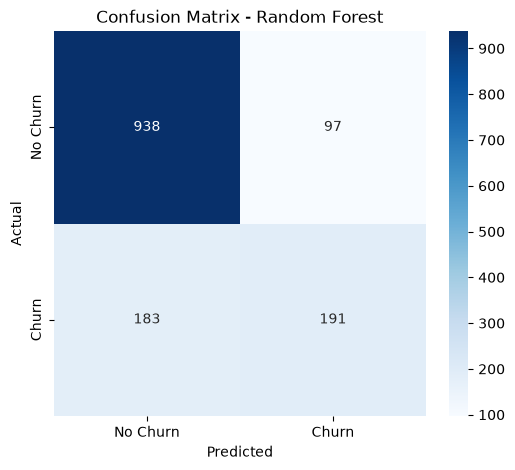

True Negatives: 938 | False Positives: 97
False Negatives: 183 | True Positives: 191


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp}")
print(f"False Negatives: {fn} | True Positives: {tp}")

💰 Business Impact (Real Dollar Terms)

In [45]:
missed_revenue = 183 * 74.44 * 12  # FN customers × avg monthly charge × 12 months
print(f"Estimated annual revenue lost due to missed churners: ${missed_revenue:,.2f}")

Estimated annual revenue lost due to missed churners: $163,470.24


Precision, Recall, F1

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Store all predictions in a dictionary
models_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'CatBoost': y_pred_cb
}

# Calculate metrics for each model
results = []
for name, y_pred in models_predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).round(4)
print(results_df.sort_values('F1-Score', ascending=False))

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8013     0.6556  0.5294    0.5858
3              XGBoost    0.7977     0.6422  0.5374    0.5852
4             CatBoost    0.8006     0.6576  0.5187    0.5800
2        Random Forest    0.8013     0.6632  0.5107    0.5770
1        Decision Tree    0.7814     0.6162  0.4679    0.5319


Precision-Recall AUC (PR-AUC)

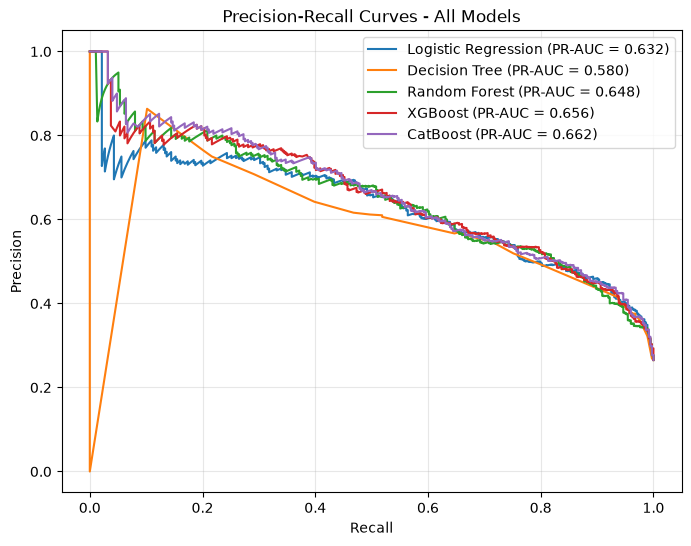

In [47]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate PR-AUC for each model (need probability scores, not just class predictions)
models_dict = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'CatBoost': cb
}

plt.figure(figsize=(8,6))

for name, model in models_dict.items():
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of "Churn" class
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()